In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow import keras
from sklearn.model_selection import train_test_split
import numpy as np



In [78]:
#Daten vorbereiten
df = pd.read_csv("melting-point-data/morganfeatures.csv")
y = np.array(df["Tm"]).reshape(-1,1)

# df.drop(columns = df.filter(regex = "Group"))
# df_X = df.drop(["Unnamed: 0", "Tm", "MolWt" ], axis = 1)
# df_X = df.drop(["Unnamed: 0", "Tm", "id", "SMILES" ], axis = 1)
df_X = df.drop([ "Tm", "Unnamed: 0"], axis = 1)



X = np.array(df_X)

#Daten skalieren
x_scale = StandardScaler()
y_scale = StandardScaler()

X = x_scale.fit_transform(X)
y = y_scale.fit_transform(y)

# pca = PCA(n_components=500)
# X = pca.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.33, random_state=42)




In [79]:
df_X

,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,HeavyAtomMolWt,ExactMolWt,NumValenceElectrons,...,MACCS_157,MACCS_158,MACCS_159,MACCS_160,MACCS_161,MACCS_162,MACCS_163,MACCS_164,MACCS_165,MACCS_166
0,11.537037,11.537037,2.668981,-4.947338,0.479530,28.200000,162.032,162.032,161.990419,58,...,0,0,0,0,0,0,0,0,1,0
1,3.470111,3.470111,1.207271,1.207271,0.446879,11.529412,217.271,206.183,217.089149,80,...,0,0,0,0,1,1,1,0,1,0
2,4.446898,4.446898,0.992407,0.992407,0.625839,10.833333,160.220,148.124,160.100048,62,...,0,1,0,1,1,1,1,0,1,0
3,9.425694,9.425694,1.071759,-1.071759,0.422302,5.500000,84.074,80.042,84.021129,32,...,1,0,1,1,0,0,0,1,0,0
4,4.232083,4.232083,0.597176,0.597176,0.540734,14.142857,118.245,104.133,118.081621,44,...,0,0,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2657,5.139082,5.139082,0.708333,0.708333,0.489475,7.500000,143.411,139.379,141.918490,26,...,0,0,0,0,0,0,0,0,0,0
2658,7.756944,7.756944,1.400463,-1.736111,0.476306,10.333333,144.388,144.388,142.909632,34,...,0,0,0,0,1,0,0,0,0,0
2659,2.224537,2.224537,1.326944,1.326944,0.547649,10.500000,156.228,144.132,156.093900,60,...,0,0,0,1,0,1,1,0,1,0
2660,11.457114,11.457114,0.204401,0.204401,0.653309,10.357143,184.238,172.142,184.088815,70,...,0,0,0,1,0,1,1,1,1,0


In [80]:
#Modell aufbauen

callback = keras.callbacks.EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

num_features = X_train.shape[1]

model = Sequential()
model.add(Dense(512, input_dim = num_features, activation = 'relu', kernel_regularizer=l2(0.001) ))
model.add(Dropout(0.4))
model.add(Dense(256, activation = 'relu', kernel_regularizer=l2(0.001) ))
model.add(Dropout(0.3))
model.add(Dense(64, activation = 'relu', kernel_regularizer=l2(0.001) ))
model.add(Dropout(0.2))

model.add(Dense(1, activation = 'linear' ))

model.summary()


/Users/enricofritz/Documents/Meltingpoint_rep/Melting_point_project/venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 512)            │     1,245,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_24 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_25 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,393,537 (5.32 MB)

 Trainable params: 1,393,537 (5.32 MB)

 Non-trainable params: 0 (0.00 B)

In [81]:
model.compile(optimizer=Adam(learning_rate=0.001), loss = "mae", metrics=["mae"])
history = model.fit(X_train,y_train, verbose = True, validation_split = 0.1, epochs = 500, callbacks=[callback])

Epoch 1/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.9033 - mae: 0.7589 - val_loss: 1.5820 - val_mae: 0.5388
Epoch 2/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.5470 - mae: 0.5460 - val_loss: 1.5237 - val_mae: 0.5557
Epoch 3/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.4371 - mae: 0.4867 - val_loss: 1.4203 - val_mae: 0.4858
Epoch 4/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.3617 - mae: 0.4402 - val_loss: 1.4421 - val_mae: 0.5337
Epoch 5/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2969 - mae: 0.4005 - val_loss: 1.3443 - val_mae: 0.4620
Epoch 6/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.2493 - mae: 0.3805 - val_loss: 1.3285 - val_mae: 0.4756
Epoch 7/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1776 - mae: 0.3401 - val_loss: 1.2563 - val_mae: 0.4351
Epoch 8/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1359 - mae: 0.3299 - val_loss: 1.2399 - val_mae: 0.4503
Epoch 9/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.101

In [82]:
y_predict = y_scale.inverse_transform(model.predict(X_test))
y_true = y_scale.inverse_transform(y_test)

mae = np.mean(np.abs(y_predict - y_true))

mae

28/28 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


np.float64(31.701599776579382)

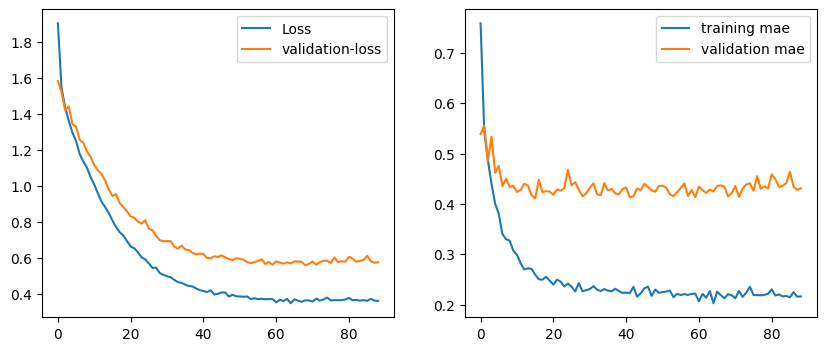

In [83]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize = (10,4))

ax1.plot(history.history['loss'], label = "Loss")
ax1.plot(history.history['val_loss'], label = "validation-loss")

# ax1.plot(history.history['val_loss'])


ax2.plot(history.history['mae'], label= "training mae")
ax2.plot(history.history['val_mae'], label = "validation mae")

ax1.legend()
ax2.legend()